# Creating and Discretizing Pipe in 1D 

In [16]:
import gmsh
import jax.numpy as jnp
import numpy as np

# Create pipe mesh in Gmsh
gmsh.initialize()
gmsh.model.add("pipe")

# Define pipe geometry: 1m long, 0.1m radius
L, R = 1.0, 0.1
tol = 1e-3  # tolerance for floating point comparisons

gmsh.model.occ.addCylinder(0, 0, 0,  # start point
                            L, 0, 0,  # direction and length
                            R)        # radius


gmsh.model.occ.synchronize()
# Get all 2D entities (surfaces)
surfaces = gmsh.model.getEntities(dim=2)
print("All surfaces:")

wall_tags    = []
inlet_tags   = []
outlet_tags  = []

for dim, tag in surfaces:
    # Get the bounding box of each surface, to determine which is which
    xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(dim, tag)
    
    # printing surfaces coordinates out to visualize the bounding boxes/their corredinates to confirm
    print(f"  Surface {tag}: "
          f"x=[{xmin:.3f},{xmax:.3f}] "
          f"y=[{ymin:.3f},{ymax:.3f}] "
          f"z=[{zmin:.3f},{zmax:.3f}]")
    
    # using bounding box more flexible approach to classify surfaces than relying on tags
    x_extent = xmax - xmin
    y_extent = ymax - ymin
    z_extent = zmax - zmin

    # Inlet cap: flat face at x=0
    # A flat circular cap at x=0 will have xmin≈xmax≈0
    if abs(xmin) < tol and abs(xmax) < tol:
        inlet_tags.append(tag)

    # Outlet cap: flat face at x=L
    # Same logic but at x=L
    elif abs(xmin - L) < tol and abs(xmax - L) < tol:
        outlet_tags.append(tag)

    # Wall: the cylindrical surface spans the full length
    # It extends from x=0 to x=L and has radial extent in y and z
    else:
        wall_tags.append(tag)

print(f"Identified wall surfaces   : {wall_tags}")
print(f"Identified inlet surfaces  : {inlet_tags}")
print(f"Identified outlet surfaces : {outlet_tags}")

'''
# assigning surfaces based on visual inspection of coordinates printed out
# Volume is unambiguous - there's only one
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")

gmsh.model.addPhysicalGroup(2, [1], tag=1)
gmsh.model.setPhysicalName(2, 1, "wall")

gmsh.model.addPhysicalGroup(2, [2], tag=2)
gmsh.model.setPhysicalName(2, 2, "outlet")

gmsh.mode.setPhysicalName(2, 3, "inlet")

# Tag the volume too -- JAX-FEM needs this
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")
'''


# Now assign physical groups with tags, not hard coded method 
gmsh.model.addPhysicalGroup(2, wall_tags,   tag=1)
gmsh.model.setPhysicalName(2, 1, "wall")
gmsh.model.addPhysicalGroup(2, inlet_tags,  tag=2)
gmsh.model.setPhysicalName(2, 2, "inlet")
gmsh.model.addPhysicalGroup(2, outlet_tags, tag=3)
gmsh.model.setPhysicalName(2, 3, "outlet")

# Get all surfaces that bound the fluid volume
# getBoundary returns (dim, tag) pairs — the surfaces forming the volume's skin
volume_boundary = gmsh.model.getBoundary([(3, 1)], oriented=False)
volume_boundary_tags = [tag for dim, tag in volume_boundary]

print(f"Surfaces bounding the fluid volume: {volume_boundary_tags}")
print(f"Wall tags   : {wall_tags}")
print(f"Inlet tags  : {inlet_tags}")
print(f"Outlet tags : {outlet_tags}")

# Sanity check — every boundary surface should be accounted for
all_surface_tags = set(wall_tags + inlet_tags + outlet_tags)
boundary_set = set(volume_boundary_tags)

unaccounted = boundary_set - all_surface_tags
if unaccounted:
    print(f"WARNING: these surfaces are on the volume boundary but "
          f"not assigned to any group: {unaccounted}")
else:
    print("OK: all volume boundary surfaces are accounted for")

# Assign the volume — using only the 3D entity, no surfaces
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")

gmsh.model.mesh.generate(3)

# Set mesh size
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.05)
gmsh.model.mesh.generate(3)
# For ParaView visualization, temporarily remove the volume 
# physical group so only surfaces export to VTK
gmsh.model.removePhysicalGroups([(3, 4)])  # remove fluid volume group
gmsh.write("pipe.vtk")                      # now only surfaces write out

# Re-add it for the .msh (already written, so this is just housekeeping)
gmsh.model.addPhysicalGroup(3, [1], tag=4)
gmsh.model.setPhysicalName(3, 4, "fluid")


# After meshing...
elementTypes, elementTags, _ = gmsh.model.mesh.getElements(dim=3, tag=-1)
tetTags = elementTags[0]

qualities = gmsh.model.mesh.getElementQualities(tetTags, "gamma")

print(f"Min quality: {np.min(qualities):.4f}")
print(f"Mean quality: {np.mean(qualities):.4f}")
print(f"Elements below 0.2: {np.sum(np.array(qualities) < 0.2)}")

gmsh.finalize()
gmsh.model

All surfaces:
  Surface 1: x=[-0.000,1.000] y=[-0.100,0.100] z=[-0.100,0.100]
  Surface 2: x=[1.000,1.000] y=[-0.100,0.100] z=[-0.100,0.100]
  Surface 3: x=[-0.000,0.000] y=[-0.100,0.100] z=[-0.100,0.100]
Identified wall surfaces   : [1]
Identified inlet surfaces  : [3]
Identified outlet surfaces : [2]
Surfaces bounding the fluid volume: [1, 2, 3]
Wall tags   : [1]
Inlet tags  : [3]
Outlet tags : [2]
OK: all volume boundary surfaces are accounted for
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 40%] Meshing curve 2 (Line)
Info    : [ 70%] Meshing curve 3 (Circle)
Info    : Done meshing 1D (Wall 0.000126416s, CPU 0.000158s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Cylinder, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00399179s, CPU 0.003856s)
Info    : Meshing 3D...
Info    : 3D Meshing 1 volume with 1 conne

gmsh.model

# 1D two-phase solver in jax, for general pipe 1D

1D Two-Phase Mixture Flow Solver
  Grid:       N=100 cells, dx=0.0100 m
  Phase 1:    ρ=1000.0 kg/m³, φ₀=0.7
  Phase 2:    ρ=1.0 kg/m³, φ₀=0.30
  ΔP drive:   1000 Pa
  Drag coeff: 50.0
  t_end:      2.0 s

  t=0.0968s  step=  500  dt=1.44e-04  vol_err=0.00e+00  max|u1|=0.1281  max|u2|=27.8151
  t=0.1671s  step= 1000  dt=1.39e-04  vol_err=0.00e+00  max|u1|=0.2284  max|u2|=28.8058
  t=0.2362s  step= 1500  dt=1.38e-04  vol_err=0.00e+00  max|u1|=0.3273  max|u2|=28.9920
  t=0.3051s  step= 2000  dt=1.37e-04  vol_err=0.00e+00  max|u1|=0.4258  max|u2|=29.1034
  t=0.3737s  step= 2500  dt=1.37e-04  vol_err=0.00e+00  max|u1|=0.5239  max|u2|=29.2019
  t=0.4421s  step= 3000  dt=1.37e-04  vol_err=0.00e+00  max|u1|=0.6218  max|u2|=29.2946
  t=0.5102s  step= 3500  dt=1.36e-04  vol_err=0.00e+00  max|u1|=0.7195  max|u2|=29.3862
  t=0.5782s  step= 4000  dt=1.36e-04  vol_err=0.00e+00  max|u1|=0.8170  max|u2|=29.4897
  t=0.6459s  step= 4500  dt=1.35e-04  vol_err=0.00e+00  max|u1|=0.9140  max|u2|=29.6155
  

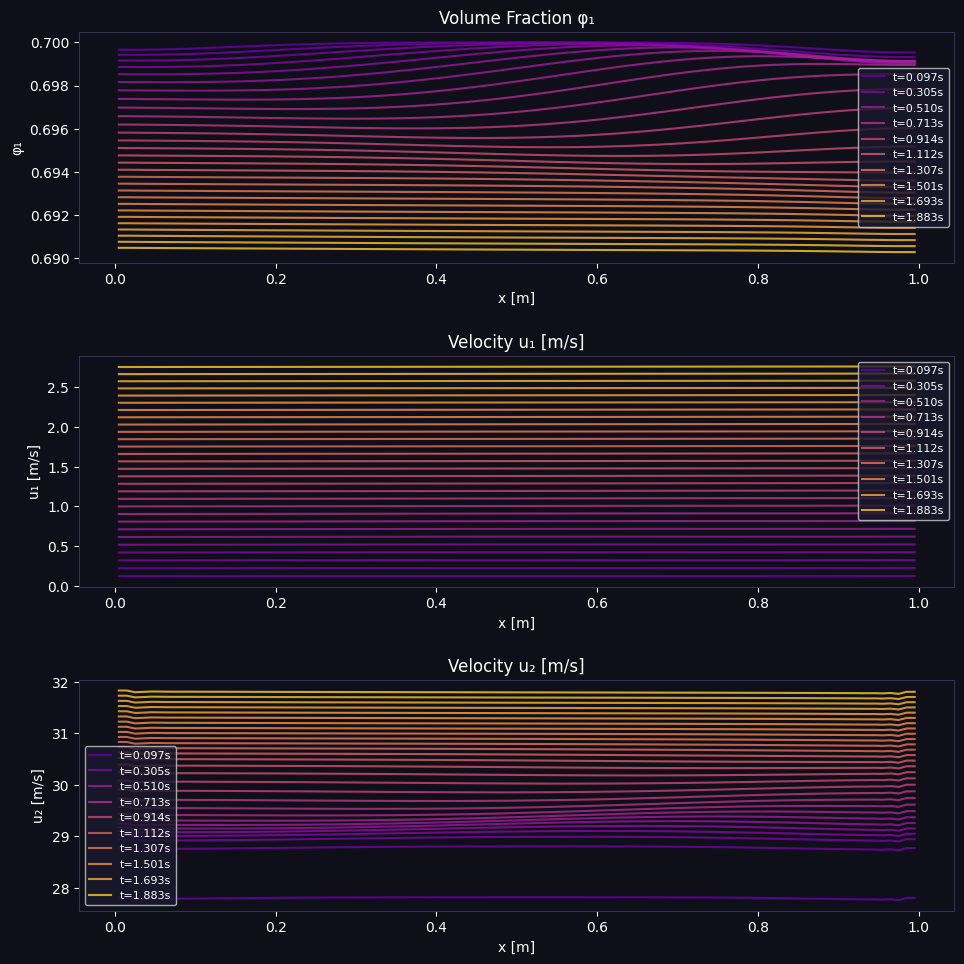

Plot saved to mixture_flow_result.png


In [3]:
"""
1D Two-Phase Mixture Flow Solver in JAX
========================================

Solves the two-phase mixture theory equations for flow in a 1D pipe using
explicit time integration with a pressure projection method to enforce
volume conservation.

GOVERNING EQUATIONS (per phase α = 1, 2):

  Mass:
    ∂(φ_α ρ_α)/∂t + ∂(φ_α ρ_α u_α)/∂x = 0

  Momentum:
    ∂(φ_α ρ_α u_α)/∂t + ∂(φ_α ρ_α u_α² + φ_α p)/∂x
        = p ∂φ_α/∂x + M_α

  Volume constraint:
    φ₁ + φ₂ = 1   (enforced via pressure projection)

  Inter-phase drag (Stokes):
    M₁ =  C_d φ₁ φ₂ (u₂ - u₁)
    M₂ = -M₁

SOLUTION SEQUENCE PER TIME STEP:
  1. Advance mass equations    → new φ₁, φ₂
  2. Advance momentum eqs      → intermediate velocities u₁*, u₂*
  3. Pressure Poisson solve    → pressure correction dp
  4. Velocity projection       → volume-conserving u₁, u₂
  5. Algebraic cleanup         → enforce φ₂ = 1 - φ₁

NUMERICAL METHODS:
  - Spatial:  Lax-Friedrichs flux (upwind-biased, stable for convection)
  - Time:     Forward Euler (RK2 commented out at bottom for easy upgrade)
  - Pressure: Thomas algorithm (tridiagonal solve — exact in 1D, O(N))
  - BCs:      Fixed pressure inlet, zero-gradient outlet
"""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

# Force JAX to use 64-bit floats — critical for numerical stability in PDEs.
# By default JAX uses 32-bit, which accumulates floating point error quickly
# in time-marching solvers.
jax.config.update("jax_enable_x64", True)


# =============================================================================
# SECTION 1: GRID SETUP
# =============================================================================
# We use a finite volume method on a uniform 1D grid.
# Each "cell" is a control volume of width dx.
# Variables are stored at cell centers.
# Fluxes are computed at cell faces (between centers).
#
#   |--dx--|--dx--|--dx--|
#   |  0   |  1   |  2   |  ...  |  N-1  |   <- cell indices
#   ^      ^      ^                        <- face indices (N+1 faces total)
#   0      1      2                N
#
# Cell centers: x[i] = (i + 0.5) * dx
# Faces:        x_face[i] = i * dx

def make_grid(L, N):
    """
    Create a uniform 1D finite volume grid.
    
    L : float — pipe length [m]
    N : int   — number of cells
    
    Returns dx (cell width) and x (cell center coordinates).
    """
    dx = L / N
    x  = (jnp.arange(N) + 0.5) * dx   # cell centers, shape (N,)
    return dx, x


# =============================================================================
# SECTION 2: INITIAL CONDITIONS
# =============================================================================
# At t=0 we set the state of every cell in the pipe.
# Everything is at rest initially (u=0), with uniform volume fractions
# and a linear pressure gradient from inlet to outlet.

def initial_conditions(x, L, phi1_0, rho1, rho2, p_inlet, p_outlet):
    """
    Set initial conditions across all cells.

    x       : (N,) cell center coordinates
    L       : pipe length
    phi1_0  : initial volume fraction of phase 1 (uniform)
    rho1    : density of phase 1 [kg/m³]
    rho2    : density of phase 2 [kg/m³]
    p_inlet : inlet pressure [Pa]
    p_outlet: outlet pressure [Pa]

    Returns a dict of state arrays, each shape (N,).
    """
    N = len(x)

    phi1 = jnp.full(N, phi1_0)
    phi2 = 1.0 - phi1                          # volume constraint at t=0

    u1   = jnp.zeros(N)                        # both phases at rest
    u2   = jnp.zeros(N)

    # Linear pressure profile: high at inlet, low at outlet
    # This is the driving force for the flow
    p    = p_inlet + (p_outlet - p_inlet) * (x / L)

    return dict(phi1=phi1, phi2=phi2, u1=u1, u2=u2, p=p,
                rho1=jnp.full(N, rho1), rho2=jnp.full(N, rho2))


# =============================================================================
# SECTION 3: CFL TIME STEP
# =============================================================================
# The CFL (Courant-Friedrichs-Lewy) condition is a stability requirement for
# explicit time integration. It says: information cannot travel more than one
# cell per time step. If dt is too large, the numerical scheme sees a wave
# "jump over" a cell and the solution blows up.
#
# dt < CFL * dx / max_wavespeed
#
# We use CFL=0.4 (conservative — 0.5 is the theoretical limit for
# Lax-Friedrichs but we stay below it for safety).

def compute_dt(state, dx, cfl=0.4, dt_max=1e-3):
    """
    Compute the maximum stable time step from the CFL condition.
    Wave speeds are the phase velocities plus pressure wave speed.
    For incompressible phases we use max(|u1|, |u2|) as a proxy.
    """
    max_speed = jnp.maximum(
        jnp.max(jnp.abs(state['u1'])),
        jnp.max(jnp.abs(state['u2']))
    )
    max_speed = jnp.maximum(max_speed, 1e-6)
    dt_cfl = cfl * dx / max_speed
    return jnp.minimum(dt_cfl, dt_max)   # never exceed dt_max


# =============================================================================
# SECTION 4: LAX-FRIEDRICHS FLUX
# =============================================================================
# The Lax-Friedrichs scheme is the simplest stable numerical flux for
# hyperbolic conservation laws like our mass and momentum equations.
#
# For a conservation law  ∂q/∂t + ∂F(q)/∂x = 0,
# the Lax-Friedrichs numerical flux at face i+1/2 is:
#
#   F_{i+1/2} = 0.5*(F(q_i) + F(q_{i+1})) - 0.5*α*(q_{i+1} - q_i)
#
# where α = max wave speed (numerical dissipation coefficient).
#
# The first term is the average of left and right fluxes (central scheme).
# The second term adds dissipation proportional to the jump in q — this
# is what makes the scheme stable by damping oscillations at faces.
#
# Indexing: if q has shape (N,), the output has shape (N-1,) — one flux
# value per interior face.

def lax_friedrichs_flux(F, q, alpha):
    """
    Compute Lax-Friedrichs numerical flux at all interior faces.

    F     : (N,) physical flux at cell centers
    q     : (N,) conserved variable at cell centers
    alpha : scalar max wave speed for dissipation

    Returns flux at N-1 interior faces, shape (N-1,).
    
    F[:-1] = left cell of each face (cell i)
    F[1:]  = right cell of each face (cell i+1)
    """
    return 0.5 * (F[:-1] + F[1:]) - 0.5 * alpha * (q[1:] - q[:-1])


# =============================================================================
# SECTION 5: STEP 1 — ADVANCE MASS EQUATIONS
# =============================================================================
# Mass equation for phase α:
#   ∂(φ_α ρ_α)/∂t = -∂(φ_α ρ_α u_α)/∂x
#
# We time-integrate the conserved variable m_α = φ_α ρ_α.
# The flux is F_mα = φ_α ρ_α u_α (mass flux).
#
# After advancing m_α, we recover φ_α = m_α / ρ_α (since ρ_α is constant).

def advance_mass(state, dt, dx):
    """
    Advance mass equations for both phases by one time step.
    Returns updated phi1, phi2 (interior cells only, shape N-2).
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']

    # Conserved mass variables
    m1 = phi1 * rho1    # shape (N,)
    m2 = phi2 * rho2

    # Physical mass fluxes at cell centers
    F_m1 = phi1 * rho1 * u1
    F_m2 = phi2 * rho2 * u2

    # Max wave speed for Lax-Friedrichs dissipation
    alpha = jnp.maximum(jnp.max(jnp.abs(u1)), jnp.max(jnp.abs(u2)))
    alpha = jnp.maximum(alpha, 1e-6)

    # Numerical fluxes at faces, shape (N-1,)
    f_m1 = lax_friedrichs_flux(F_m1, m1, alpha)
    f_m2 = lax_friedrichs_flux(F_m2, m2, alpha)

    # Flux divergence at interior cells, shape (N-2,)
    # (f[1:] - f[:-1]) / dx = net flux out of each interior cell
    div_m1 = (f_m1[1:] - f_m1[:-1]) / dx
    div_m2 = (f_m2[1:] - f_m2[:-1]) / dx

    # Forward Euler advance of conserved mass (interior cells only)
    m1_new = m1[1:-1] - dt * div_m1   # shape (N-2,)
    m2_new = m2[1:-1] - dt * div_m2

    # Recover volume fractions from updated mass
    phi1_new = m1_new / rho1[1:-1]
    phi2_new = m2_new / rho2[1:-1]

    # Clip to [0,1] — small overshoots from numerics can push fractions
    # slightly negative; clipping prevents unphysical states
    phi1_new = jnp.clip(phi1_new, 0.0, 1.0)
    phi2_new = jnp.clip(phi2_new, 0.0, 1.0)

    return phi1_new, phi2_new


# =============================================================================
# SECTION 6: STEP 2 — ADVANCE MOMENTUM EQUATIONS (INTERMEDIATE VELOCITIES)
# =============================================================================
# Momentum equation for phase α:
#   ∂(φ_α ρ_α u_α)/∂t = -∂(φ_α ρ_α u_α² + φ_α p)/∂x
#                        + p ∂φ_α/∂x
#                        + M_α
#
# The non-conservative term p ∂φ_α/∂x appears because φ_α multiplies p
# in the momentum flux — when you expand the divergence you get this
# extra term. It ensures the sum of all phase momentum equations gives
# the correct mixture momentum equation.
#
# M_α is the inter-phase drag: M₁ = C_d φ₁ φ₂ (u₂ - u₁), M₂ = -M₁
# The drag is proportional to the volume fractions of both phases
# (more drag when both phases are present) and the velocity difference.
#
# These are INTERMEDIATE velocities u* — not yet volume-conserving.
# The pressure projection in Step 3 will correct them.

def advance_momentum(state, dt, dx, drag_coeff):
    """
    Advance momentum equations for both phases (intermediate step).
    Returns intermediate velocities u1_star, u2_star (interior, shape N-2).
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']
    p    = state['p']

    # Conserved momentum variables
    mom1 = phi1 * rho1 * u1
    mom2 = phi2 * rho2 * u2

    # Physical momentum fluxes (convection + pressure)
    F_mom1 = phi1 * rho1 * u1**2 + phi1 * p
    F_mom2 = phi2 * rho2 * u2**2 + phi2 * p

    # Max wave speed
    alpha = jnp.maximum(jnp.max(jnp.abs(u1)), jnp.max(jnp.abs(u2)))
    alpha = jnp.maximum(alpha, 1e-6)

    # Numerical fluxes at faces, shape (N-1,)
    f_mom1 = lax_friedrichs_flux(F_mom1, mom1, alpha)
    f_mom2 = lax_friedrichs_flux(F_mom2, mom2, alpha)

    # Flux divergence at interior cells, shape (N-2,)
    div_mom1 = (f_mom1[1:] - f_mom1[:-1]) / dx
    div_mom2 = (f_mom2[1:] - f_mom2[:-1]) / dx

    # Non-conservative pressure term: p * d(phi)/dx
    # Central difference for phi gradient at interior cells
    dphi1_dx = (phi1[2:] - phi1[:-2]) / (2.0 * dx)   # shape (N-2,)
    dphi2_dx = (phi2[2:] - phi2[:-2]) / (2.0 * dx)
    p_int    = p[1:-1]                                  # shape (N-2,)

    # Inter-phase drag source terms (Newton's 3rd law: M1 + M2 = 0)
    u1_int = u1[1:-1]
    u2_int = u2[1:-1]
    phi1_int = phi1[1:-1]
    phi2_int = phi2[1:-1]

    M1 =  drag_coeff * phi1_int * phi2_int * (u2_int - u1_int)
    M2 = -M1

    # Advance conserved momentum, shape (N-2,)
    mom1_new = mom1[1:-1] - dt * div_mom1 + dt * p_int * dphi1_dx + dt * M1
    mom2_new = mom2[1:-1] - dt * div_mom2 + dt * p_int * dphi2_dx + dt * M2

    # Recover intermediate velocities from conserved momentum
    # Small epsilon in denominator prevents division by zero when phi → 0
    eps = 1e-10
    u1_star = mom1_new / (phi1_int * rho1[1:-1] + eps)
    u2_star = mom2_new / (phi2_int * rho2[1:-1] + eps)

    return u1_star, u2_star


# =============================================================================
# SECTION 7: STEP 3 — PRESSURE POISSON SOLVE (THOMAS ALGORITHM)
# =============================================================================
# After advancing mass and momentum, the intermediate velocities u1*, u2*
# generally do NOT satisfy volume conservation:
#
#   ∂/∂x (φ₁u₁ + φ₂u₂) ≠ 0
#
# We need to find a pressure correction dp such that after applying it,
# the corrected velocities DO satisfy volume conservation.
#
# The pressure correction equation (derived by substituting the velocity
# correction u_α = u_α* - (dt/ρ_α) * dp/dx into the divergence-free
# condition) is:
#
#   ∂/∂x [ (φ₁/ρ₁ + φ₂/ρ₂) * dp/dx ] = (1/dt) * ∂/∂x(φ₁u₁* + φ₂u₂*)
#
# This is a 1D Poisson equation for dp. In 1D with uniform grid it becomes
# a tridiagonal linear system, solved exactly in O(N) by the Thomas algorithm.
#
# The Thomas algorithm (tridiagonal matrix algorithm) is just Gaussian
# elimination specialized for tridiagonal matrices. It has two passes:
#   Forward sweep: eliminate the lower diagonal
#   Back substitution: solve from bottom to top

def solve_tridiagonal(a, b, c, d):
    """
    Solve a tridiagonal system A·x = d using the Thomas algorithm.
    
    a : (N,) lower diagonal  (a[0] unused)
    b : (N,) main diagonal
    c : (N,) upper diagonal  (c[-1] unused)
    d : (N,) right-hand side
    
    Returns x, shape (N,).
    
    NOTE: JAX does not support in-place mutation, so we use lax.scan
    to perform the forward and backward sweeps functionally.
    This is the idiomatic JAX way to express sequential recurrences.
    """
    N = len(b)

    # --- Forward sweep ---
    # Eliminate lower diagonal by modifying b and d in place (functionally)
    # c'[0] = c[0]/b[0],  d'[0] = d[0]/b[0]
    # For i > 0:
    #   w = a[i] / b'[i-1]
    #   b'[i] = b[i] - w * c[i-1]
    #   d'[i] = d[i] - w * d'[i-1]

    def forward_step(carry, i):
        b_prev, d_prev = carry
        w      = a[i] / b_prev
        b_curr = b[i] - w * c[i - 1]
        d_curr = d[i] - w * d_prev
        return (b_curr, d_curr), (b_curr, d_curr)

    # Initial values for first cell
    b0 = b[0]
    d0 = d[0]

    _, (b_mod, d_mod) = jax.lax.scan(
        forward_step,
        (b0, d0),
        jnp.arange(1, N)
    )

    # Prepend the first cell values
    b_mod = jnp.concatenate([jnp.array([b0]), b_mod])
    d_mod = jnp.concatenate([jnp.array([d0]), d_mod])

    # --- Back substitution ---
    # x[-1] = d'[-1] / b'[-1]
    # x[i]  = (d'[i] - c[i] * x[i+1]) / b'[i]

    def backward_step(x_next, i):
        x_curr = (d_mod[i] - c[i] * x_next) / b_mod[i]
        return x_curr, x_curr

    x_last = d_mod[-1] / b_mod[-1]

    _, x_interior = jax.lax.scan(
        backward_step,
        x_last,
        jnp.arange(N - 2, -1, -1)   # iterate N-2 down to 0
    )

    # Reverse because scan went backwards
    x = jnp.concatenate([x_interior[::-1], jnp.array([x_last])])
    return x


def pressure_poisson_solve(phi1, phi2, rho1, rho2, u1_star, u2_star, dx, dt):
    """
    Solve for pressure correction dp that makes the corrected velocities
    satisfy volume conservation.

    Interior cells only — phi, rho, u arrays are all shape (N-2,) here,
    representing the N-2 interior cells (excluding boundary cells).

    Returns dp, shape (N-2,), the pressure correction at interior cells.
    """
    N = len(phi1)   # number of interior cells

    # Mobility coefficient: how easily pressure drives volume flux
    # Higher mobility = pressure more effective at redistributing volume
    mob = phi1 / rho1 + phi2 / rho2    # shape (N-2,), units [m³·s/kg]

    # Mobility at faces (average of neighboring cells), shape (N-3,)
    mob_face = 0.5 * (mob[:-1] + mob[1:])

    # Right-hand side: divergence of mixture volumetric flux
    # div(φ₁u₁* + φ₂u₂*) at interior cells, shape (N-2,)
    # We use a simple central-ish difference on the interior cells
    mix_flux = phi1 * u1_star + phi2 * u2_star   # shape (N-2,)

    # Divergence of mix_flux using one-sided differences
    # For the interior-of-interior cells we have neighbors; for edge cells
    # we use one-sided. Here we use a simple centered difference where possible.
    rhs = jnp.zeros(N)
    # Interior of interior: shape (N-4,)
    rhs = rhs.at[1:-1].set((mix_flux[2:] - mix_flux[:-2]) / (2.0 * dx))
    # Edge cells: one-sided
    rhs = rhs.at[0].set((mix_flux[1] - mix_flux[0]) / dx)
    rhs = rhs.at[-1].set((mix_flux[-1] - mix_flux[-2]) / dx)

    rhs = rhs / dt   # scale by 1/dt

    # Build tridiagonal system for the pressure correction
    # Discretization of ∂/∂x[mob * ∂dp/∂x] = rhs
    # At cell i (0-indexed, N interior cells):
    #   main diagonal:  -(mob_face[i] + mob_face[i-1]) / dx²
    #   upper diagonal: mob_face[i] / dx²
    #   lower diagonal: mob_face[i-1] / dx²
    # Boundary conditions: dp = 0 at both ends (Dirichlet)

    dx2 = dx * dx

    # Main diagonal, shape (N,)
    b_diag = jnp.zeros(N)
    b_diag = b_diag.at[0].set(-mob_face[0] / dx2)               # left BC
    b_diag = b_diag.at[-1].set(-mob_face[-1] / dx2)             # right BC
    b_diag = b_diag.at[1:-1].set(
        -(mob_face[1:] + mob_face[:-1]) / dx2
    )
    # Ensure no zeros on main diagonal
    b_diag = jnp.where(jnp.abs(b_diag) < 1e-14,
                        jnp.full_like(b_diag, -1.0), b_diag)

    # Upper diagonal, shape (N,) — c[-1] unused
    c_diag = jnp.zeros(N)
    c_diag = c_diag.at[:-1].set(mob_face / dx2)

    # Lower diagonal, shape (N,) — a[0] unused
    a_diag = jnp.zeros(N)
    a_diag = a_diag.at[1:].set(mob_face / dx2)

    # Set Dirichlet BC: dp = 0 at boundaries means row 0 and row N-1
    # become trivial: 1*dp[0] = 0, 1*dp[-1] = 0
    a_diag = a_diag.at[0].set(0.0)
    b_diag = b_diag.at[0].set(1.0)
    c_diag = c_diag.at[0].set(0.0)
    rhs    = rhs.at[0].set(0.0)

    a_diag = a_diag.at[-1].set(0.0)
    b_diag = b_diag.at[-1].set(1.0)
    c_diag = c_diag.at[-1].set(0.0)
    rhs    = rhs.at[-1].set(0.0)

    dp = solve_tridiagonal(a_diag, b_diag, c_diag, rhs)
    return dp


# =============================================================================
# SECTION 8: STEP 4 — VELOCITY PROJECTION
# =============================================================================
# Correct the intermediate velocities using the pressure gradient:
#
#   u_α = u_α* - (dt / ρ_α) * dp/dx
#
# This subtracts the pressure-driven acceleration that restores volume
# conservation. After this correction, ∂/∂x(φ₁u₁ + φ₂u₂) ≈ 0.

def project_velocities(u1_star, u2_star, dp, phi1, phi2, rho1, rho2, dx, dt):
    """
    Project intermediate velocities onto the volume-conserving subspace.
    
    u1_star, u2_star : intermediate velocities, shape (N-2,)
    dp               : pressure correction, shape (N-2,)
    Returns corrected u1, u2, shape (N-2,).
    """
    # Pressure gradient at interior cells via central difference
    # dp has shape (N-2,); we difference within it
    dp_dx = jnp.zeros_like(dp)
    dp_dx = dp_dx.at[1:-1].set((dp[2:] - dp[:-2]) / (2.0 * dx))
    dp_dx = dp_dx.at[0].set((dp[1] - dp[0]) / dx)
    dp_dx = dp_dx.at[-1].set((dp[-1] - dp[-2]) / dx)

    eps = 1e-10
    u1_new = u1_star - (dt / (rho1 + eps)) * dp_dx
    u2_new = u2_star - (dt / (rho2 + eps)) * dp_dx

    return u1_new, u2_new


# =============================================================================
# SECTION 9: BOUNDARY CONDITIONS
# =============================================================================
# Boundary cells (index 0 and N-1) are not part of the interior solve.
# We set them here to enforce:
#   Inlet (left, x=0):  fixed pressure p_inlet, zero-gradient velocity
#   Outlet (right, x=L): fixed pressure p_outlet, zero-gradient velocity
#
# Zero-gradient means: copy the value from the nearest interior cell.
# This is a common "outflow" BC — it lets the flow exit without reflection.
#
# JAX arrays are immutable, so .at[].set() returns a NEW array.
# This is not in-place mutation — JAX traces these as functional updates.

def apply_boundary_conditions(state, phi1_int, phi2_int, u1_int, u2_int,
                               p_inlet, p_outlet):
    """
    Pad interior arrays (N-2,) with boundary values to produce full (N,) arrays.
    
    Interior arrays come from the PDE solve (Steps 1-4).
    Boundary cells are set from BCs.
    """
    N = len(state['phi1'])   # total cells including boundaries

    # --- Volume fractions ---
    # Interior values from mass advance; boundaries from zero-gradient
    phi1 = jnp.concatenate([phi1_int[:1],    # inlet: copy first interior
                             phi1_int,
                             phi1_int[-1:]])  # outlet: copy last interior

    # Step 5: algebraic cleanup — enforce volume constraint
    # After projecting pressure and advancing mass independently,
    # small numerical errors may cause φ₁ + φ₂ ≠ 1 exactly.
    # We enforce it by defining φ₂ = 1 - φ₁ (phase 1 is "primary").
    phi2 = 1.0 - phi1

    # --- Velocities ---
    u1 = jnp.concatenate([u1_int[:1],    # inlet: zero-gradient
                           u1_int,
                           u1_int[-1:]])  # outlet: zero-gradient

    u2 = jnp.concatenate([u2_int[:1],
                           u2_int,
                           u2_int[-1:]])

    # --- Pressure ---
    # Interior pressure from previous step (we don't re-solve p everywhere,
    # only the correction dp); boundaries are fixed BCs
    p_int = state['p'][1:-1]   # keep interior pressure from last step

    p = jnp.concatenate([jnp.array([p_inlet]),
                          p_int,
                          jnp.array([p_outlet])])

    return dict(phi1=phi1, phi2=phi2, u1=u1, u2=u2, p=p,
                rho1=state['rho1'], rho2=state['rho2'])


# =============================================================================
# SECTION 10: FULL TIME STEP
# =============================================================================
# Combines all steps into one function that advances the state by dt.
# This is the function JAX will JIT-compile into a single XLA kernel.

def time_step(state, dt, dx, drag_coeff, p_inlet, p_outlet):
    """
    Advance the simulation state by one time step dt.

    Sequence:
      1. Advance mass equations         → phi1_int, phi2_int  (N-2,)
      2. Advance momentum equations     → u1_star, u2_star    (N-2,)
      3. Pressure Poisson solve         → dp                  (N-2,)
      4. Project velocities             → u1_int, u2_int      (N-2,)
      5. Apply BCs + volume cleanup     → full state          (N,)
    """
    rho1_int = state['rho1'][1:-1]
    rho2_int = state['rho2'][1:-1]

    # Step 1: advance mass
    phi1_int, phi2_int = advance_mass(state, dt, dx)

    # Step 2: advance momentum (intermediate velocities)
    u1_star, u2_star = advance_momentum(state, dt, dx, drag_coeff)

    # Step 3: pressure Poisson solve for volume conservation
    dp = pressure_poisson_solve(
        phi1_int, phi2_int,
        rho1_int, rho2_int,
        u1_star, u2_star,
        dx, dt
    )

    # Step 4: project velocities to be volume-conserving
    u1_int, u2_int = project_velocities(
        u1_star, u2_star, dp,
        phi1_int, phi2_int,
        rho1_int, rho2_int,
        dx, dt
    )

    # Step 5: apply BCs and volume fraction cleanup
    new_state = apply_boundary_conditions(
        state, phi1_int, phi2_int, u1_int, u2_int,
        p_inlet, p_outlet
    )

    return new_state


# =============================================================================
# SECTION 11: DIAGNOSTICS
# =============================================================================
# Functions to check physical conservation laws during the run.
# These are your sanity checks — if they drift, something is wrong.

def compute_diagnostics(state, dx):
    """
    Compute key diagnostic quantities for monitoring the simulation.
    
    Returns a dict of scalar values.
    """
    phi1 = state['phi1']
    phi2 = state['phi2']
    rho1 = state['rho1']
    rho2 = state['rho2']
    u1   = state['u1']
    u2   = state['u2']

    # Total mass of each phase (should be conserved, modulo BCs)
    total_mass1 = jnp.sum(phi1 * rho1) * dx
    total_mass2 = jnp.sum(phi2 * rho2) * dx

    # Volume fraction constraint violation — should be ~0 everywhere
    vol_error = jnp.max(jnp.abs(phi1 + phi2 - 1.0))

    # Mixture volumetric flux divergence — should be ~0 (volume conservation)
    mix_flux = phi1 * u1 + phi2 * u2
    div_mix_flux = jnp.max(jnp.abs(jnp.diff(mix_flux) / dx))

    return dict(
        total_mass1=total_mass1,
        total_mass2=total_mass2,
        vol_error=vol_error,
        div_mix_flux=div_mix_flux,
        max_u1=jnp.max(jnp.abs(u1)),
        max_u2=jnp.max(jnp.abs(u2)),
    )


# =============================================================================
# SECTION 12: MAIN — RUN THE SIMULATION
# =============================================================================

if __name__ == "__main__":

    # --- Physical parameters ---
    L        = 1.0      # pipe length [m]
    N        = 100      # number of cells
    rho1_val = 1000.0   # density of phase 1 (e.g. water) [kg/m³]
    rho2_val = 1.0      # density of phase 2 (e.g. air)   [kg/m³]
    phi1_0   = 0.7      # initial volume fraction of phase 1
    p_inlet  = 1.01e5   # inlet pressure [Pa]  (slightly above atmospheric)
    p_outlet = 1.00e5   # outlet pressure [Pa] (atmospheric)
    drag_coeff = 50.0   # inter-phase drag coefficient [kg/(m³·s)]
    t_end    = 2.0      # simulation end time [s]

    # --- Grid ---
    dx, x = make_grid(L, N)

    # --- Initial conditions ---
    state = initial_conditions(
        x, L, phi1_0,
        rho1_val, rho2_val,
        p_inlet, p_outlet
    )

    print("=" * 60)
    print("1D Two-Phase Mixture Flow Solver")
    print("=" * 60)
    print(f"  Grid:       N={N} cells, dx={dx:.4f} m")
    print(f"  Phase 1:    ρ={rho1_val} kg/m³, φ₀={phi1_0}")
    print(f"  Phase 2:    ρ={rho2_val} kg/m³, φ₀={1-phi1_0:.2f}")
    print(f"  ΔP drive:   {p_inlet - p_outlet:.0f} Pa")
    print(f"  Drag coeff: {drag_coeff}")
    print(f"  t_end:      {t_end} s")
    print()

    # JIT-compile the time step function.
    # JAX traces time_step once on the first call, compiles it to an XLA
    # kernel, and then every subsequent call runs the compiled version.
    # This is why JAX is fast — after the first step, there's no Python
    # overhead in the time loop at all.
    step_jit = jax.jit(
        lambda s, dt: time_step(s, dt, dx, drag_coeff, p_inlet, p_outlet)
    )

    # --- Storage for output ---
    save_every  = 500    # save state every N steps
    saved_times = []
    saved_phi1  = []
    saved_u1    = []
    saved_u2    = []

    # --- Time loop ---
    t      = 0.0
    step_n = 0

    while t < t_end:
        # Compute stable dt from CFL condition (adaptive time stepping)
        dt = float(compute_dt(state, dx, cfl=0.4))
        dt = min(dt, t_end - t)   # don't overshoot t_end

        # Advance one time step
        state = step_jit(state, dt)
        t     += dt
        step_n += 1

        # Diagnostics every save_every steps
        if step_n % save_every == 0:
            diag = compute_diagnostics(state, dx)
            print(f"  t={t:.4f}s  step={step_n:5d}  "
                  f"dt={dt:.2e}  "
                  f"vol_err={diag['vol_error']:.2e}  "
                  f"max|u1|={diag['max_u1']:.4f}  "
                  f"max|u2|={diag['max_u2']:.4f}")

            saved_times.append(t)
            saved_phi1.append(np.array(state['phi1']))
            saved_u1.append(np.array(state['u1']))
            saved_u2.append(np.array(state['u2']))

    print(f"\nDone. {step_n} steps completed.")
    
    # --- Visualization ---
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    fig.patch.set_facecolor('#0f0f1a')
    x_np = np.array(x)

    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(saved_times)))

    titles  = ['Volume Fraction φ₁', 'Velocity u₁ [m/s]', 'Velocity u₂ [m/s]']
    data    = [saved_phi1, saved_u1, saved_u2]
    ylabels = ['φ₁', 'u₁ [m/s]', 'u₂ [m/s]']

    for ax, title, series, ylabel in zip(axes, titles, data, ylabels):
        ax.set_facecolor('#0f0f1a')
        for i, (arr, color) in enumerate(zip(series, colors)):
            label = f't={saved_times[i]:.3f}s' if i % 3 == 0 else None
            ax.plot(x_np, arr, color=color, linewidth=1.5,
                    alpha=0.8, label=label)
        ax.set_xlabel('x [m]', color='white')
        ax.set_ylabel(ylabel, color='white')
        ax.set_title(title, color='white')
        ax.tick_params(colors='white')
        ax.spines[:].set_color('#333355')
        if any(l is not None for l in [ylabel]):
            ax.legend(facecolor='#1a1a2e', labelcolor='white',
                      fontsize=8, loc='best')

    plt.tight_layout(pad=2.0)
    plt.savefig("mixture_flow_result.png", dpi=150,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print("Plot saved to mixture_flow_result.png")


# =============================================================================
# APPENDIX: UPGRADING TO RK2 TIME INTEGRATION
# =============================================================================
# When you're ready to improve accuracy, replace the euler_step calls with
# this Heun's method (RK2). The structure is identical — you just evaluate
# the RHS twice and average the result.
#
# def rk2_step(state, dt, dx, drag_coeff, p_inlet, p_outlet):
#     """Heun's method (explicit RK2) — second-order accurate in time."""
#     # Stage 1: full Euler step to get intermediate state k1
#     k1 = time_step(state, dt, dx, drag_coeff, p_inlet, p_outlet)
#
#     # Stage 2: Euler step from k1
#     k2 = time_step(k1, dt, dx, drag_coeff, p_inlet, p_outlet)
#
#     # Average the two stages — this is the RK2 correction
#     # In practice: average the state arrays from state and k2
#     def avg(a, b): return 0.5 * (a + b)
#
#     return jax.tree.map(avg, state, k2)
#
# The time loop then becomes:
#   state = rk2_step(state, dt, dx, drag_coeff, p_inlet, p_outlet)
#
# RK2 is second-order accurate (error ~ dt²) vs Euler's first-order (error ~ dt).
# This means you can use larger dt for the same accuracy, or get much better
# accuracy at the same dt. The cost is two RHS evaluations per step instead of one.

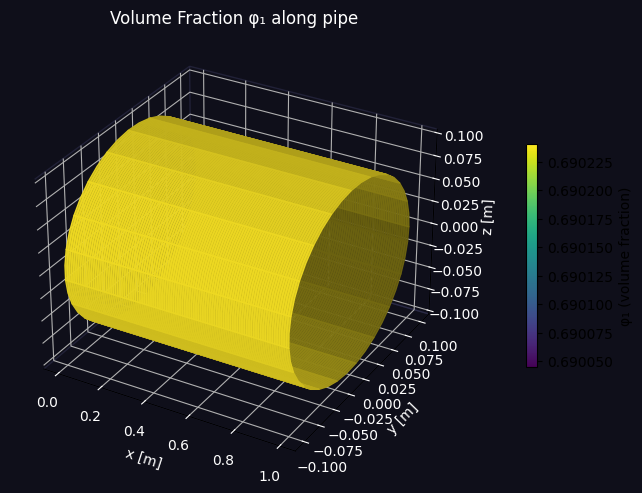

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_solution_on_pipe(x, phi1, u1, L, R=0.1):
    """
    Visualize 1D solution extruded onto a cylindrical surface.
    phi1, u1 are 1D arrays — we wrap them around the cylinder
    purely for visual representation.
    """
    fig = plt.figure(figsize=(14, 5))
    fig.patch.set_facecolor('#0f0f1a')

    # --- Build cylinder surface ---
    theta = np.linspace(0, 2 * np.pi, 40)
    x_np  = np.array(x)

    # Meshgrid: theta around circumference, x along pipe
    THETA, X = np.meshgrid(theta, x_np)
    Y = R * np.cos(THETA)
    Z = R * np.sin(THETA)

    # Extrude phi1 values: same value all around circumference at each x
    # phi1 is (N,) — broadcast to (N, 40) by repeating across theta
    PHI1 = np.array(phi1)[:, None] * np.ones_like(THETA)

    # --- Plot ---
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('#0f0f1a')

    surf = ax.plot_surface(X, Y, Z,
                           facecolors=plt.cm.viridis(PHI1 / PHI1.max()),
                           alpha=0.85,
                           rstride=1, cstride=2)

    # Colorbar
    m = plt.cm.ScalarMappable(cmap='viridis')
    m.set_array(PHI1)
    plt.colorbar(m, ax=ax, shrink=0.5, label='φ₁ (volume fraction)')

    ax.set_xlabel('x [m]', color='white')
    ax.set_ylabel('y [m]', color='white')
    ax.set_zlabel('z [m]', color='white')
    ax.set_title('Volume Fraction φ₁ along pipe', color='white')
    ax.tick_params(colors='white')
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#333355')

    plt.tight_layout()
    plt.savefig("pipe_solution.png", dpi=150,
                bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    
phi1_final, _, u1_final, _, _, u2_final, p_final = (
    state['phi1'], state['rho1'], state['u1'],
    state['phi2'], state['rho2'], state['u2'], state['p']
)

plot_solution_on_pipe(np.array(x), np.array(phi1_final), 
                      np.array(u1_final), L, R=0.1)